# PCA Manual Implementation

> All notes in Diary.



In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
np.random.seed(23)

In [4]:
mu_vec1 = np.array([0,0,0])

In [5]:
print(mu_vec1)

[0 0 0]


In [6]:
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])

In [7]:
print(cov_mat1)

[[1 0 0]
 [0 1 0]
 [0 0 1]]


In [8]:
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

In [9]:
class1_sample

array([[ 0.66698806,  0.02581308, -0.77761941],
       [ 0.94863382,  0.70167179, -1.05108156],
       [-0.36754812, -1.13745969, -1.32214752],
       [ 1.77225828, -0.34745899,  0.67014016],
       [ 0.32227152,  0.06034293, -1.04345   ],
       [-1.00994188,  0.44173637,  1.12887685],
       [-1.83806777, -0.93876863, -0.20184052],
       [ 1.04537128,  0.53816197,  0.81211867],
       [ 0.2411063 , -0.95250953, -0.13626676],
       [ 1.26724821,  0.17363364, -1.22325477],
       [ 1.41531998,  0.45771098,  0.72887584],
       [ 1.96843473, -0.54778801, -0.67941827],
       [-2.50623032,  0.14696049,  0.60619549],
       [-0.02253889,  0.01342226,  0.93594489],
       [ 0.42062266,  0.41161964, -0.07132392],
       [-0.04543758,  1.04088597, -0.09403473],
       [-0.42084395, -0.55198856, -0.12109755],
       [ 0.19014136,  0.51213739,  0.13153847],
       [-0.33161712, -1.63238628,  0.61911407],
       [-0.99257378, -0.16134639,  1.19240433]])

In [10]:
df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])

In [11]:
df.head()

,feature1,feature2,feature3
0,0.666988,0.025813,-0.777619
1,0.948634,0.701672,-1.051082
2,-0.367548,-1.137460,-1.322148
3,1.772258,-0.347459,0.670140
4,0.322272,0.060343,-1.043450


In [12]:
df['target'] = 1

In [13]:
df.head()

,feature1,feature2,feature3,target
0,0.666988,0.025813,-0.777619,1
1,0.948634,0.701672,-1.051082,1
2,-0.367548,-1.137460,-1.322148,1
3,1.772258,-0.347459,0.670140,1
4,0.322272,0.060343,-1.043450,1


In [14]:
mu_vec2 = np.array([1,1,1])

In [15]:
mu_vec2

array([1, 1, 1])

In [16]:
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])

In [17]:
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

In [18]:
df1 = pd.DataFrame(class2_sample, columns=['feature1','feature2','feature3'])

In [19]:
df1['target'] = 0

In [20]:
df = pd.concat([df, df1], ignore_index=True)

In [21]:
df = df.sample(40)

In [22]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [23]:
import plotly.express as px

In [24]:
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
                    color=df['target'].astype('str'))

In [25]:
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

In [26]:
fig.show()

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()

In [29]:
df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [30]:
covariance_matrix = np.cov([df.iloc[:,0], df.iloc[:,1], df.iloc[:,2]])

In [31]:
covariance_matrix

array([[1.02564103, 0.20478114, 0.080118  ],
       [0.20478114, 1.02564103, 0.19838882],
       [0.080118  , 0.19838882, 1.02564103]])

In [32]:
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [33]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [34]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

In [35]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [36]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

In [37]:
class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, renderer.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        FancyArrowPatch.draw(self, renderer)

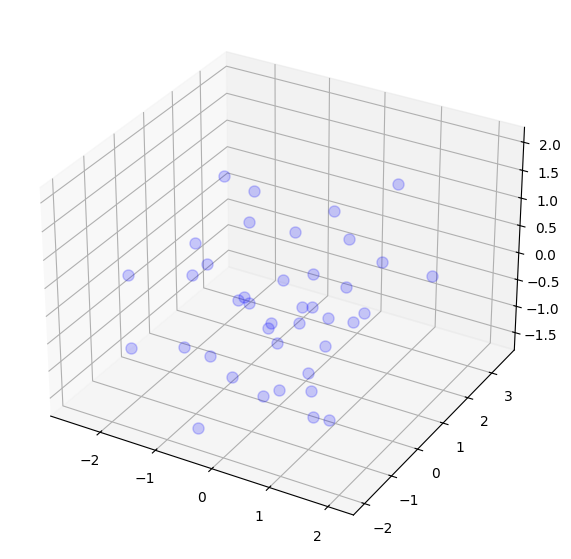

In [38]:
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)

from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        return min(zs3d)

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.get_proj())
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

In [39]:
pc = eigen_vectors[0:2]

In [40]:
transformed_df = np.dot(df.iloc[:,0:3], pc.T)

In [41]:
new_df = pd.DataFrame(transformed_df, columns=['PC1','PC2'])

In [42]:
new_df['target'] = df['target'].values

In [43]:
new_df['target'] = df['target'].values

In [44]:
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [45]:
new_df['target'] = new_df['target'].astype('str')

In [46]:
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10)

In [47]:
fig.show()

In [48]:
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))